# ReAct Challenge: Multi-Step Order Assistant

## Build a LangGraph ReAct agent that answers this kind of query:
"user": "I ordered item A123. Check the order status, estimate delivery date, and calculate how many days are left."

## Tech Used

1. LangGraph -- Graph Orchetration
2. Mock Products Data -- dict
3. Terms of Services and Company Policy(Delivery) -- RAG  

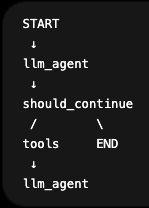

In [1]:
from typing import Annotated, Sequence, TypedDict, Literal
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from datetime import datetime

In [2]:
load_dotenv()

True

In [3]:
product_data = [
    {"id": "product-1", "status": "in_stock", "estimated_delivery_date": "2026-06-15"},
    {"id": "product-2", "status": "in_stock", "estimated_delivery_date": "2026-06-15"},
    {"id": "product-3", "status": "out_of_stock", "estimated_delivery_date": "2026-06-17"}, 
    {"id": "product-4", "status": "out_of_stock", "estimated_delivery_date": "2026-06-17"},
]

In [6]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    status: Literal["in_stock", "out_of_stock"]
    remaining_date: datetime

In [5]:
def select_product(product_id):
    return next(
        (product for product in product_data if product["id"] == product_id),
        None
    ) 

@tool
def check_status(product_id):
    """
    Check the product status by a given product id
    """

    selected_product = select_product(product_id)

    if selected_product is None:
        return {"error": "product not found"}

    return selected_product.get("status", None)


@tool
def check_estimated_delivery_date(product_id):
    """
    Check the estimated delivery date from the data
    """
    selected_product = select_product(product_id)

    return select_product.get("estimated_delivery_date")


@tool
def check_remianing_days_to_deliver(product_id):
    """
    Check how many days are left to deliver the item to the customer
    """

    selected_product = select_product(product_id)

    # Convert the delivery date(string) into datetime object 
    delivery_date = datetime.strptime(selected_product["estimated_delivery_date"], "%Y-%m-%d")
 
    remaining_days = (delivery_date.date() - datetime.now().date()).days

    return remaining_days
    

In [7]:
class Llm:
    def __init__(self, model): 
        self.model = model
        self.client = None

    def initiate_llm(self): 
        self.client = ChatOpenAI()

    def reason(self, system_msg: SystemMessage, user_msg:Sequence[BaseMessage]):
        try:
            if self.client == None: 
                self.initiate_llm()

            return self.client.invoke([system_msg] + user_msg) 
                
        except Exception as e:
            raise f"Calling LLM caused an error: {e}"

In [8]:
def llm_agent(state: State) -> State:
    system_message = SystemMessage(content="You are a customer service agent that serves user questions and inquiries".strip())

    llm = Llm(model="gpt-5.4-mini")
    response = llm.reason(system_message, state["messages"])

    return {"messages": [response]}

In [9]:
def should_continue(state): 
    """
    Conditional node that decides whether to continue or end the tool calling
    """

    messages = state["messages"]
    last_message = messages[-1]

    if hasattr(last_message, "tool_calls", None):
        return "continue"

    return "end"